# ERA5 Running Total Results: Net & Hot-Only Mortality Impact Summary

Computes and plots running-total net and hot-only mortality impacts (age-weighted, June–July)
for the current ERA5-based effects run, including summary statistics (mean, 17th/83rd
percentiles) and aggregate impact maps.

**Data:**
- **Projection effects (running total)** — `2608_effects_running_total.zarr`
- **Impact region polygons** — `POREALLAS_REGIONS_POLYGONS_URI`
- **Socioeconomic data** — `POREALLAS_SOCIOECONOMICS_URI` (2026)

In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

# Load Data

In [ ]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]


In [ ]:
# Total Running Effects
EFFECTS_RUNNING = "2608_effects_running_total.zarr"

In [5]:
# Projection Effects
effect_running = xr.open_datatree(
    os.path.join(DATA_DIR, EFFECTS_RUNNING), consolidated=False
)
baseline_period = analysis_utils.get_baseline_period(effect_running, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

# Mortality Impact

In [8]:
# Net Mortality
impact_net = analysis_utils.compute_impact(
    effect_running,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=False,
    age_weight=True,
    chunks={"sample": -1, "region": "auto"},
).sel(month=[6, 7])

# Stats
# Mean
print(int(impact_net.mean(dim="sample").sum(dim=["region", "month"]).values))
# Quantiles
print(int(impact_net.sum(dim=["region", "month"]).quantile(q=0.17, dim="sample").values))
print(int(impact_net.sum(dim=["region", "month"]).quantile(q=0.83, dim="sample").values))

99456
-18015
216000


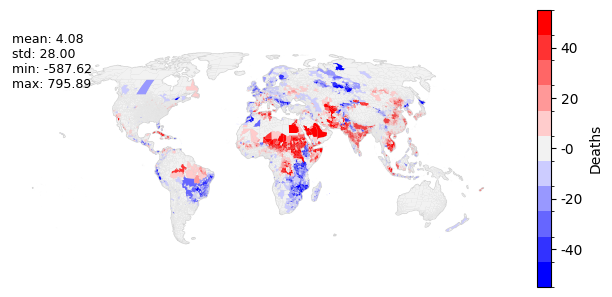

In [12]:
_polygons_impact_net = analysis_utils.xarray_to_gpd(impact_net.mean(dim=["sample"]), _polygons)

annotation = analysis_utils.build_stats_text(
    impact_net.mean(dim=["sample"]).sum(dim="month")
)
fig = analysis_utils.plot_aggregate(
    _polygons_impact_net,
    col="age_weighted_impact",
    agg="sum",
    n_colors=11,
    cm="bwr",
    sup_title="",
    annotation=annotation,
    cbar_label=impact_net.units,
)

fig.savefig("2608_net_running_total_agg.png", dpi=600, bbox_inches="tight")

In [9]:
# Hot Mortality
impact_hot = analysis_utils.compute_impact(
    effect_running,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="hotonly",
    rate=False,
    age_weight=True,
    chunks={"sample": -1, "region": "auto"},
).sel(month=[6, 7])

# Stats
# Mean
print(int(impact_hot.mean(dim="sample").sum(dim=["region", "month"]).values))
# Quantiles
print(int(impact_hot.sum(dim=["region", "month"]).quantile(q=0.17, dim="sample").values))
print(int(impact_hot.sum(dim=["region", "month"]).quantile(q=0.83, dim="sample").values))

198362
138331
276740


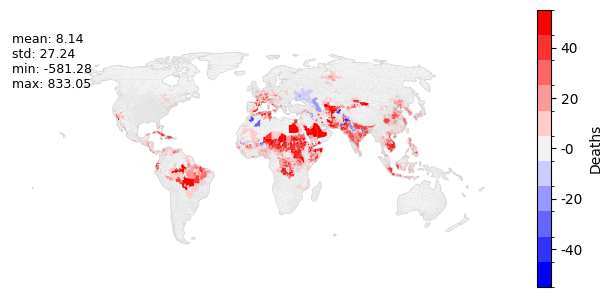

In [13]:
_polygons_impact_hot = analysis_utils.xarray_to_gpd(impact_hot.mean(dim=["sample"]), _polygons)

annotation = analysis_utils.build_stats_text(
    impact_hot.mean(dim=["sample"]).sum(dim="month")
)
fig = analysis_utils.plot_aggregate(
    _polygons_impact_hot,
    col="age_weighted_impact",
    agg="sum",
    n_colors=11,
    cm="bwr",
    sup_title="",
    annotation=annotation,
    cbar_label=impact_hot.units,
)

fig.savefig("2608_hot_running_total_agg.png", dpi=600, bbox_inches="tight")